<a href="https://colab.research.google.com/github/kang25-gif/Intro-to-Data-Analytics/blob/main/B07_Project_private.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initilize


# 新段落

In [77]:
!wget https://github.com/Marcusshi/BA780-07/raw/main/cdnnba_2024.csv.zip -O cdnnba_2024.csv.zip
!wget https://github.com/Marcusshi/BA780-07/raw/main/matchups_2024.csv -O matchups_2024.csv

--2025-09-29 22:11:43--  https://github.com/Marcusshi/BA780-07/raw/main/cdnnba_2024.csv.zip
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Marcusshi/BA780-07/main/cdnnba_2024.csv.zip [following]
--2025-09-29 22:11:43--  https://raw.githubusercontent.com/Marcusshi/BA780-07/main/cdnnba_2024.csv.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31300185 (30M) [application/zip]
Saving to: ‘cdnnba_2024.csv.zip’

cdnnba_2024.csv.zip 100%[===================>]  29.85M  --.-KB/s    in 0.1s    

2025-09-29 22:11:48 (220 MB/s) - ‘cdnnba_2024.csv.zip’ saved [31300185/31300185]

--2025-09-29 22:11:48--  

We downloaded the `cdnnba_2024.csv.zip` dataset directly from GitHub using the `wget` command and saved it locally.  
This ensures reproducibility and guarantees that everyone can access the same version of the raw data for analysis.


In [78]:
!unzip -o cdnnba_2024.csv.zip -d data

Archive:  cdnnba_2024.csv.zip
  inflating: data/cdnnba_2024.csv    
  inflating: data/__MACOSX/._cdnnba_2024.csv  


We extracted the `cdnnba_2024.csv.zip` file into the `data` directory using the `unzip` command.  
The `-o` flag ensures any existing files are overwritten, guaranteeing we always work with the latest dataset version.  


In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cdnnba = pd.read_csv("/content/data/cdnnba_2024.csv")

cdnnba.head(5)


,actionNumber,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,...,stealPersonId,pointsTotal,assistPlayerNameInitial,assistPersonId,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,gameId
0,2,PT12M00.00S,2024-11-13T00:10:24.900Z,1,REGULAR,period,start,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22400001
1,4,PT11M58.00S,2024-11-13T00:10:26.800Z,1,REGULAR,jumpball,recovered,NaN,1630811,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22400001
2,7,PT11M43.00S,2024-11-13T00:10:40Z,1,REGULAR,3pt,Jump Shot,NaN,1642258,27.414586,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22400001
3,8,PT11M43.00S,2024-11-13T00:10:40Z,1,REGULAR,block,NaN,NaN,1628369,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22400001
4,9,PT11M42.00S,2024-11-13T00:10:41Z,1,REGULAR,rebound,offensive,NaN,1642258,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22400001


In [80]:
matchups = pd.read_csv("/content/matchups_2024.csv")
matchups.head(5)

,game_id,away_team_id,home_team_id,team_id,team_name,team_city,team_tricode,team_slug,person_id,first_name,...,matchup_three_pointers_made,matchup_three_pointers_attempted,matchup_three_pointers_percentage,help_blocks,help_field_goals_made,help_field_goals_attempted,help_field_goals_percentage,matchup_free_throws_made,matchup_free_throws_attempted,shooting_fouls
0,22400001,1610612737,1610612738,1610612738,Celtics,Boston,BOS,celtics,1627759,Jaylen,...,0,0,0.0,0,0,0,0,0,0,0
1,22400001,1610612737,1610612738,1610612738,Celtics,Boston,BOS,celtics,1627759,Jaylen,...,0,0,0.0,0,0,0,0,1,2,1
2,22400001,1610612737,1610612738,1610612738,Celtics,Boston,BOS,celtics,1627759,Jaylen,...,3,5,0.6,0,0,0,0,3,4,2
3,22400001,1610612737,1610612738,1610612738,Celtics,Boston,BOS,celtics,1627759,Jaylen,...,0,0,0.0,0,0,0,0,0,0,0
4,22400001,1610612737,1610612738,1610612738,Celtics,Boston,BOS,celtics,1627759,Jaylen,...,0,0,0.0,0,0,0,0,0,0,0


We successfully loaded the `cdnnba_2024.csv` dataset into a Pandas DataFrame and displayed the first five rows.  
This confirms the file was read correctly and provides an initial preview of the dataset’s structure and columns for further cleaning and analysis.

# Shot Efficiency Analysis  

**Question:**  
How do different **action types** (2PT, 3PT, Free Throws) and **shot subtypes** (Jump Shot, Layup, Hook, Dunk, Free Throw) compare in terms of scoring efficiency? Which shot types contribute most effectively to team offense?

In [81]:
cols_keep = [
    "actionNumber", "gameId", "period",
    "playerName", "personId",
    "actionType", "subType",
    "shotResult", "periodType", "pointsTotal"
]

shot_actions = ["2pt", "3pt", "freethrow"]
shots = cdnnba.loc[cdnnba["actionType"].isin(shot_actions), cols_keep].copy()

shots["ms_make"] = shots["shotResult"].astype(str).str.lower().eq("made")

pts_map = {"2pt": 2, "3pt": 3, "freethrow": 1}
shots["ms_points"] = shots["actionType"].map(pts_map).fillna(0)
shots.loc[~shots["ms_make"], "ms_points"] = 0

sub = shots["subType"].astype(str).str.strip()
shots["ms_subtype"] = shots["subType"]
shots.loc[sub.str.contains(r"\bof\b", case=False, regex=True), "ms_subtype"] = "Free Throw"

valid_subtypes = {"Jump Shot", "Layup", "Hook", "Dunk", "Free Throw"}
shots = shots[shots["ms_subtype"].isin(valid_subtypes)].copy()

print("shots shape:", shots.shape)
shots.head(10)

shots shape: (259460, 13)


,actionNumber,gameId,period,playerName,personId,actionType,subType,shotResult,periodType,pointsTotal,ms_make,ms_points,ms_subtype
2,7,22400001,1,Risacher,1642258,3pt,Jump Shot,Missed,REGULAR,NaN,False,0,Jump Shot
5,10,22400001,1,Johnson,1630552,2pt,Jump Shot,Missed,REGULAR,NaN,False,0,Jump Shot
7,12,22400001,1,White,1628401,3pt,Jump Shot,Missed,REGULAR,NaN,False,0,Jump Shot
16,21,22400001,1,Johnson,1630552,3pt,Jump Shot,Made,REGULAR,3.0,True,3,Jump Shot
17,23,22400001,1,Brown,1627759,3pt,Jump Shot,Made,REGULAR,3.0,True,3,Jump Shot
19,27,22400001,1,Capela,203991,freethrow,1 of 2,Missed,REGULAR,NaN,False,0,Free Throw
21,29,22400001,1,Capela,203991,freethrow,2 of 2,Missed,REGULAR,NaN,False,0,Free Throw
23,31,22400001,1,Brown,1627759,3pt,Jump Shot,Missed,REGULAR,NaN,False,0,Jump Shot
25,34,22400001,1,Wallace,1630811,3pt,Jump Shot,Missed,REGULAR,NaN,False,0,Jump Shot
27,36,22400001,1,Capela,203991,2pt,Layup,Made,REGULAR,2.0,True,2,Layup


We cleaned and filtered the play-by-play dataset to keep only real shot attempts (2PT, 3PT, Free Throw).  
Points were assigned consistently (2, 3, or 1) with misses set to zero, and shot subtypes were simplified into five categories: *Jump Shot, Layup, Hook, Dunk,* and *Free Throw*.  
This creates a clean dataset (`shots`) that is ready for efficiency analysis.  


/tmp/ipython-input-67015027.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_act, y="Action", x="ppa", ax=ax1, palette="Blues_r")
/tmp/ipython-input-67015027.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_sub, y="ms_subtype", x="ppa", ax=ax2, palette="Blues_r")


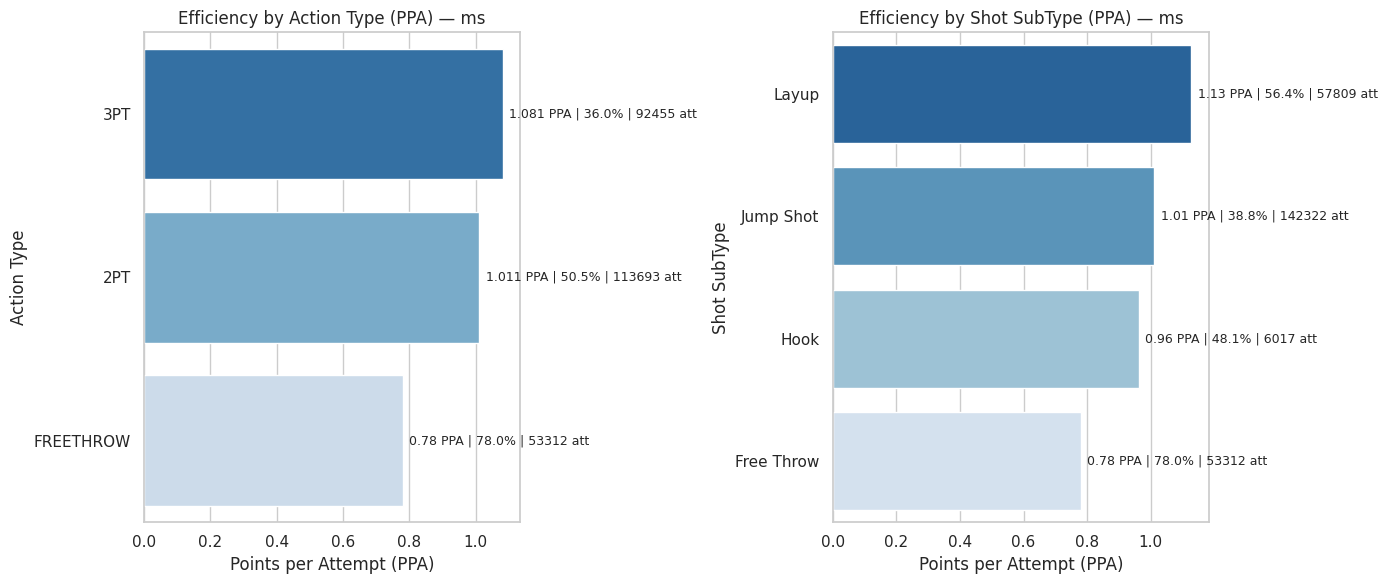

In [82]:
# summaries
summary_act = (
    shots.groupby("actionType", dropna=False)
         .agg(attempts=("ms_make","size"),
              makes=("ms_make","sum"),
              make_rate=("ms_make","mean"),
              ppa=("ms_points","mean"))
         .sort_values(["ppa","make_rate"], ascending=False)
         .reset_index()
)
summary_act["Make %"] = (summary_act["make_rate"]*100).round(1)
summary_act["PPA"] = summary_act["ppa"].round(3)
summary_act["Action"] = summary_act["actionType"].str.upper()

summary_sub = (
    shots.groupby("ms_subtype", dropna=False)
         .agg(attempts=("ms_make","size"),
              makes=("ms_make","sum"),
              make_rate=("ms_make","mean"),
              ppa=("ms_points","mean"))
         .sort_values("ppa", ascending=False)
         .reset_index()
)
summary_sub["Make %"] = (summary_sub["make_rate"]*100).round(1)
summary_sub["PPA"] = summary_sub["ppa"].round(2)

# plotting
sns.set(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14,6), sharex=False)

# Action Type
sns.barplot(data=summary_act, y="Action", x="ppa", ax=ax1, palette="Blues_r")
ax1.set_title("Efficiency by Action Type (PPA) — ms")
ax1.set_xlabel("Points per Attempt (PPA)")
ax1.set_ylabel("Action Type")
for i, r in summary_act.iterrows():
    ax1.text(r["ppa"]+0.02, i, f'{r["PPA"]} PPA | {r["Make %"]}% | {int(r["attempts"])} att',
             va="center", fontsize=9)

# SubType
sns.barplot(data=summary_sub, y="ms_subtype", x="ppa", ax=ax2, palette="Blues_r")
ax2.set_title("Efficiency by Shot SubType (PPA) — ms")
ax2.set_xlabel("Points per Attempt (PPA)")
ax2.set_ylabel("Shot SubType")
for i, r in summary_sub.iterrows():
    ax2.text(r["ppa"]+0.02, i, f'{r["PPA"]} PPA | {r["Make %"]}% | {int(r["attempts"])} att',
             va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Findings:

1. **2PT and 3PT shots are nearly equal in overall efficiency**:  
   - 2PT shots average ~1.01 PPA with a **50.5% make rate**.  
   - 3PT shots average slightly higher at ~1.08 PPA, but with a lower **36.0% make rate**.  
   This reflects the tradeoff: 3PTs are harder to make, but reward more points when successful.

2. **Free Throws remain efficient in accuracy, but lower in PPA**:  
   - Free Throws show the highest **make rate** (78%) but only yield **0.78 PPA**.  
   - This is expected since each free throw is worth only 1 point, limiting efficiency compared to field goals.

3. **By shot subtype, Layups stand out as the most efficient field attempt**:  
   - Layups achieve ~1.13 PPA at a **56.4% make rate**.  
   - This balance of accuracy and scoring value makes Layups a key offensive option near the rim.

4. **Jump Shots are less efficient despite being the most common attempt**:  
   - They deliver ~1.01 PPA at just **38.8% accuracy**, showing that volume doesn’t necessarily equal efficiency.  
   - Over-reliance on Jump Shots can drag down team offensive efficiency.

5. **Hooks trail behind Layups and Jump Shots**:  
   - Hooks generate ~0.96 PPA with **48.1% accuracy**, effective in specific post situations but less reliable overall.

6. **Strategic Implication**:  
   Teams can optimize offense by emphasizing **Layups and 3PTs** — Layups for consistent efficiency inside, and 3PTs for high-value scoring when accuracy is managed. Free Throws remain a vital complementary source of points, but Jump Shots should be better selected to avoid inefficiency.


# Quarter by Quarter Strategy (Stephanie)
Question: Do teams change their shot mix (2pt vs 3pt) by quarter, and does it differ at home vs away, including OT?

Metric: For each quarter × home/away, count 2PA and 3PA, then show 100% stacked bars (share of 2pt vs 3pt).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1) Sort events so score diffs are meaningful
qs_events = cdnnba.copy()
qs_sort_cols = [c for c in ["gameId","orderNumber","actionNumber"] if c in qs_events.columns]
qs_events = qs_events.sort_values(qs_sort_cols if qs_sort_cols else ["gameId"]).reset_index(drop=True)

# 2) Per-row score increments → who scored?
qs_events["qs_d_home"] = qs_events.groupby("gameId")["scoreHome"].diff().fillna(0).clip(lower=0)
qs_events["qs_d_away"] = qs_events.groupby("gameId")["scoreAway"].diff().fillna(0).clip(lower=0)

# 3) Infer home/away tricode per game (use scoring evidence)
qs_home_map = (qs_events.loc[qs_events["qs_d_home"]>0]
               .groupby("gameId")["teamTricode"].agg(lambda s: s.mode().iloc[0]))
qs_away_map = (qs_events.loc[qs_events["qs_d_away"]>0]
               .groupby("gameId")["teamTricode"].agg(lambda s: s.mode().iloc[0]))

qs_events["qs_homeTricode"] = qs_events["gameId"].map(qs_home_map)
qs_events["qs_awayTricode"] = qs_events["gameId"].map(qs_away_map)
qs_events["qs_home_away"] = None
qs_events.loc[qs_events["teamTricode"] == qs_events["qs_homeTricode"], "qs_home_away"] = "Home"
qs_events.loc[qs_events["teamTricode"] == qs_events["qs_awayTricode"], "qs_home_away"] = "Away"
qs_events = qs_events[qs_events["qs_home_away"].notna()].copy()

# 4) Quarter label (merge all periods >=5 into 'OT')
quarter_map = {1:"Q1", 2:"Q2", 3:"Q3", 4:"Q4"}
qs_events["qs_quarter"] = qs_events["period"].map(quarter_map).fillna("OT")

# 5) Shot attempts (2pt / 3pt). If shotResult exists, require it.
qs_is_2pt = qs_events["actionType"].eq("2pt")
qs_is_3pt = qs_events["actionType"].eq("3pt")
qs_is_shot = qs_is_2pt | qs_is_3pt
qs_has_result = qs_events["shotResult"].notna() if "shotResult" in qs_events.columns else True
qs_events["qs_is_2pt_attempt"] = (qs_is_2pt & qs_has_result).astype(int)
qs_events["qs_is_3pt_attempt"] = (qs_is_3pt & qs_has_result).astype(int)

# 6) Aggregate: Quarter × Home/Away
qs_mix = (qs_events
          .groupby(["qs_quarter","qs_home_away"], as_index=False)
          .agg(two_pa=("qs_is_2pt_attempt","sum"),
               three_pa=("qs_is_3pt_attempt","sum")))

qs_mix["total_att"]   = qs_mix["two_pa"] + qs_mix["three_pa"]
qs_mix["share_3pt"]   = qs_mix["three_pa"] / qs_mix["total_att"].replace(0, np.nan)
qs_mix["share_2pt"]   = 1 - qs_mix["share_3pt"]

(0.3, 0.7)

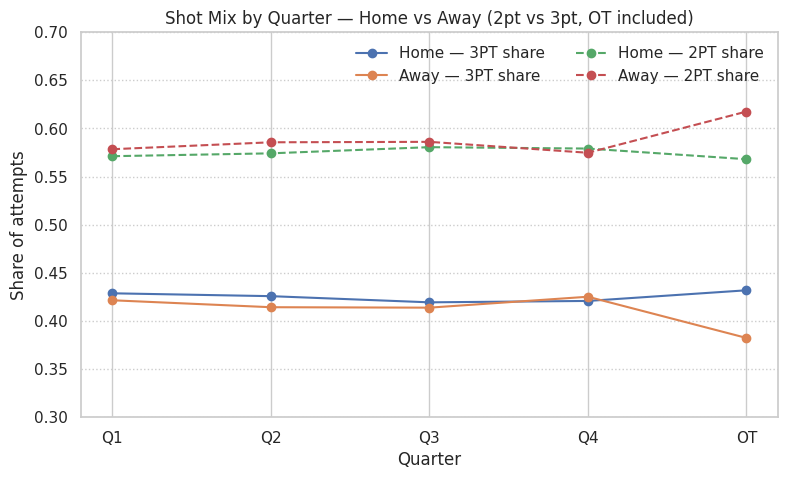

In [ ]:
# Order quarters on the x-axis
qs_order_quarters = ["Q1","Q2","Q3","Q4","OT"]
qs_plot = qs_mix.copy()
qs_plot["qs_quarter"] = pd.Categorical(qs_plot["qs_quarter"], categories=qs_order_quarters, ordered=True)

# Pivot to wide for easy line plotting
wide3 = qs_plot.pivot(index="qs_quarter", columns="qs_home_away", values="share_3pt")
wide2 = qs_plot.pivot(index="qs_quarter", columns="qs_home_away", values="share_2pt")

x = np.arange(len(qs_order_quarters))

sns.set(style="whitegrid")
plt.figure(figsize=(9,5))
ax = plt.gca()

# Four lines: Home-3pt, Away-3pt, Home-2pt, Away-2pt
ax.plot(x, wide3.reindex(qs_order_quarters)["Home"].values, marker="o", label="Home — 3PT share")
ax.plot(x, wide3.reindex(qs_order_quarters)["Away"].values, marker="o", label="Away — 3PT share")
ax.plot(x, wide2.reindex(qs_order_quarters)["Home"].values, marker="o", linestyle="--", label="Home — 2PT share")
ax.plot(x, wide2.reindex(qs_order_quarters)["Away"].values, marker="o", linestyle="--", label="Away — 2PT share")

# Cosmetics
ax.set_xticks(x)
ax.set_xticklabels(qs_order_quarters)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Share of attempts")
ax.set_xlabel("Quarter")
ax.set_title("Shot Mix by Quarter — Home vs Away (2pt vs 3pt, OT included)")
ax.legend(ncols=2, frameon=False)
ax.grid(True, axis="y", linestyle=":")
ax.set_ylim(0.30, 0.70)


NameError: name 'Patch' is not defined

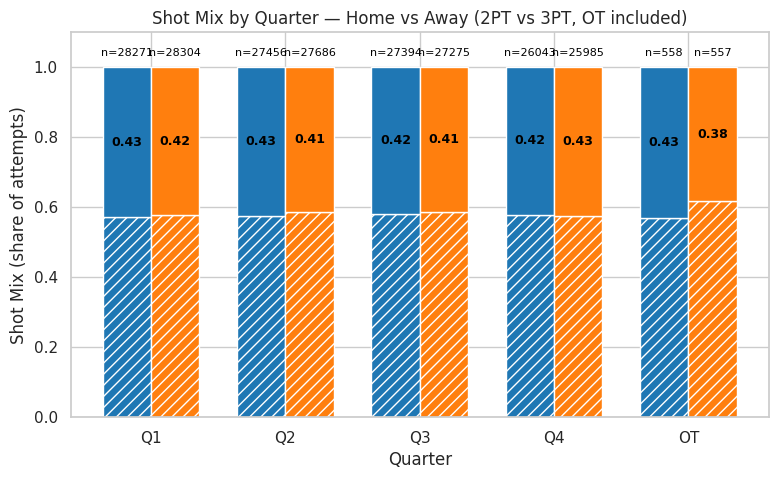

In [ ]:
# Order quarters on the x-axis (including OT)
qs_order_quarters = ["Q1","Q2","Q3","Q4","OT"]

# Ensure ordering
qs_plot = qs_mix.copy()
qs_plot["qs_quarter"] = pd.Categorical(qs_plot["qs_quarter"], categories=qs_order_quarters, ordered=True)
qs_plot = qs_plot.sort_values(["qs_quarter","qs_home_away"]).reset_index(drop=True)

# Colors fixed by home/away
home_color = "#1f77b4"  # blue
away_color = "#ff7f0e"  # orange

# Bar geometry: two bars per quarter (Home left, Away right)
x = np.arange(len(qs_order_quarters))
bar_w = 0.36

def row_for(q, ha):
    r = qs_plot[(qs_plot["qs_quarter"]==q) & (qs_plot["qs_home_away"]==ha)]
    return r.iloc[0] if len(r) else None

sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(9,5))

for i, q in enumerate(qs_order_quarters):
    for ha, dx, color in [("Home", -bar_w/2, home_color), ("Away", +bar_w/2, away_color)]:
        r = row_for(q, ha)
        if r is None:
            continue
        x_pos = x[i] + dx
        share2 = float(r["share_2pt"]) if pd.notna(r["share_2pt"]) else 0.0
        share3 = float(r["share_3pt"]) if pd.notna(r["share_3pt"]) else 0.0

        # Bottom segment = 2PT share (use hatch to distinguish 2PT vs 3PT)
        ax.bar(x_pos, share2, width=bar_w, color=color, hatch="///", label=None)
        # Top segment = 3PT share
        ax.bar(x_pos, share3, width=bar_w, bottom=share2, color=color, label=None)

        # Label the 3PT share inside the 3PT segment
        if share3 > 0:
            ax.annotate(f"{share3:.2f}",
                        xy=(x_pos, share2 + share3/2), xytext=(0,0),
                        textcoords="offset points", ha="center", va="center", fontsize=9, color="black", weight="bold")

        # Optional: total attempts on top of bar
        ax.annotate(f'n={int(r["total_att"])}',
                    xy=(x_pos, 1.02), xytext=(0,2),
                    textcoords="offset points", ha="center", va="bottom", fontsize=8, color="black")

# Axes & cosmetics
ax.set_xticks(x)
ax.set_xticklabels(qs_order_quarters)
ax.set_ylim(0, 1.10)
ax.set_ylabel("Shot Mix (share of attempts)")
ax.set_xlabel("Quarter")
ax.set_title("Shot Mix by Quarter — Home vs Away (2PT vs 3PT, OT included)")

# Legends: color => home/away; hatch => 2PT/3PT
legend_handles = [
    Patch(facecolor=home_color, label="Home"),
    Patch(facecolor=away_color, label="Away"),
    Patch(facecolor="gray", hatch="///", label="2PT share", edgecolor="gray", alpha=0.0),
    Patch(facecolor="gray", label="3PT share", edgecolor="gray", alpha=0.0),
]
ax.legend(handles=legend_handles, ncols=2, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.15))

plt.tight_layout()
plt.show()

In [ ]:
from io import StringIO
import pandas as pd
import re

# --- Load dataset ---
df = pd.read_csv("cdnnba_2024.csv")

# --- BEFORE: structure + missingness ---
print("=== BEFORE: DataFrame Structure ===")
buf = StringIO()
df.info(buf=buf)
print(buf.getvalue())

print("\n=== BEFORE: Missing Values (Top 10) ===")
missing_before = (
    df.isna().sum()
      .to_frame("Missing Count")
      .assign(MissingPct=lambda d: d["Missing Count"] / len(df))
      .sort_values("Missing Count", ascending=False)
)
display(missing_before.head(10))

# --- Cleaning steps ---
# Keep only substitution events
subs = df[df["actionType"].str.contains("substitution", case=False, na=False)].copy()

# Parse game clock into minutes elapsed in quarter
def parse_clock(clock):
    m = re.match(r"PT(\d+)M(\d+)", str(clock))
    if not m:
        return None
    minutes, seconds = int(m.group(1)), int(m.group(2))
    total_seconds_left = minutes * 60 + seconds
    return (720 - total_seconds_left) / 60  # 12*60 seconds = 720

subs["minute_elapsed"] = subs["clock"].map(parse_clock)

# Drop rows with bad parse
subs = subs.dropna(subset=["minute_elapsed"]).copy()

# Create 1-minute bins
subs["minute_bin"] = pd.cut(
    subs["minute_elapsed"],
    bins=range(0, 13),  # 0–12 minutes
    right=False,
    include_lowest=True
)

# --- AFTER: structure + missingness ---
print("=== AFTER: Subset Structure (Substitutions Only) ===")
buf = StringIO()
subs.info(buf=buf)
print(buf.getvalue())

print("\n=== AFTER: Missing Values (Top 10) ===")
missing_after = (
    subs.isna().sum()
       .to_frame("Missing Count")
       .assign(MissingPct=lambda d: d["Missing Count"] / len(subs))
       .sort_values("Missing Count", ascending=False)
)
display(missing_after.head(10))

print("\nSo what: Substitutions isolated, clocks parsed, invalid rows removed, ready for analysis ✅")

FileNotFoundError: [Errno 2] No such file or directory: 'cdnnba_2024.csv'

# Free throw Success Rate


Here is the analysis for success rate in freethrow by Home vs Away

In [38]:
import numpy as np

The cdnnba file do not contain "HomeAway' columns which defined which row are acted by Home team or Away team. So, overhere we need to merge cdnnba file with matchups file which has the home and away information we needed. We merged a new columns named "HomeAway" for better analysis. Below are the code and the head of merged dataframe.

In [39]:
combined_df['HomeAway'] = np.where(
    combined_df['teamId'] == combined_df['home_team_id'], 'Home',
    np.where(combined_df['teamId'] == combined_df['away_team_id'], 'Away', None)
)


combined_df.head(5)

,actionNumber,clock,timeActual,period,periodType,actionType,subType,qualifiers,personId,x,...,assistTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,gameId,game_id,home_team_id,away_team_id,HomeAway
0,2,PT12M00.00S,2024-11-13T00:10:24.900Z,1,REGULAR,period,start,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,22400001,22400001.0,1.610613e+09,1.610613e+09,None
1,4,PT11M58.00S,2024-11-13T00:10:26.800Z,1,REGULAR,jumpball,recovered,NaN,1630811,NaN,...,NaN,NaN,NaN,NaN,NaN,22400001,22400001.0,1.610613e+09,1.610613e+09,Away
2,7,PT11M43.00S,2024-11-13T00:10:40Z,1,REGULAR,3pt,Jump Shot,NaN,1642258,27.414586,...,NaN,NaN,NaN,NaN,NaN,22400001,22400001.0,1.610613e+09,1.610613e+09,Away
3,8,PT11M43.00S,2024-11-13T00:10:40Z,1,REGULAR,block,NaN,NaN,1628369,NaN,...,NaN,NaN,NaN,NaN,NaN,22400001,22400001.0,1.610613e+09,1.610613e+09,Home
4,9,PT11M42.00S,2024-11-13T00:10:41Z,1,REGULAR,rebound,offensive,NaN,1642258,NaN,...,NaN,NaN,NaN,NaN,NaN,22400001,22400001.0,1.610613e+09,1.610613e+09,Away


Here is the filtered Dataframe that only shows the relevent information we might need for analysis.

In [40]:
FT_cols_keep = [
    "actionNumber", "gameId", "period", "periodType",
    "playerName", "personId",
    "actionType", "subType",
    "shotResult", "periodType", "scoreAway", "scoreHome", "HomeAway"
]

Freethrow_act = ["freethrow"]
FT_filter = combined_df.loc[cdnnba["actionType"].isin(Freethrow_act), FT_cols_keep].copy()


FT_filter.head(10)

,actionNumber,gameId,period,periodType,playerName,personId,actionType,subType,shotResult,periodType,scoreAway,scoreHome,HomeAway
19,27,22400001,1,REGULAR,Capela,203991,freethrow,1 of 2,Missed,REGULAR,3,3,Away
21,29,22400001,1,REGULAR,Capela,203991,freethrow,2 of 2,Missed,REGULAR,3,3,Away
31,43,22400001,1,REGULAR,Brown,1627759,freethrow,1 of 2,Made,REGULAR,7,6,Home
32,44,22400001,1,REGULAR,Brown,1627759,freethrow,2 of 2,Missed,REGULAR,7,6,Home
52,68,22400001,1,REGULAR,Risacher,1642258,freethrow,1 of 2,Missed,REGULAR,9,8,Away
54,70,22400001,1,REGULAR,Risacher,1642258,freethrow,2 of 2,Missed,REGULAR,9,8,Away
76,96,22400001,1,REGULAR,Holiday,201950,freethrow,1 of 2,Made,REGULAR,11,11,Home
85,105,22400001,1,REGULAR,Holiday,201950,freethrow,2 of 2,Made,REGULAR,11,12,Home
92,113,22400001,1,REGULAR,Brown,1627759,freethrow,1 of 2,Made,REGULAR,13,13,Home
95,117,22400001,1,REGULAR,Brown,1627759,freethrow,2 of 2,Made,REGULAR,13,14,Home


Below are the main code for calculate the freethrow success rate by Home vs. Away.

In [73]:
# code for total success rate.
FT_total = FT_filter.groupby("HomeAway", dropna=False).size()
FT_made = FT_filter[FT_filter["shotResult"] == "Made"].groupby("HomeAway", dropna=False).size()
FT_missed = FT_filter[FT_filter["shotResult"] == "Missed"].groupby("HomeAway", dropna=False).size()

success_rate = ((FT_made / FT_total) * 100).round(2)

home_success_rate = success_rate.get("Home")
away_success_rate = success_rate.get("Away")

# code for success rate by subtype.
ft_success_rate_by_side_by_subtype = (
    FT_filter.groupby(["HomeAway", "subType"])["shotResult"]
    .apply(lambda x: (x == "Made").mean() * 100)
    .round(2)
)

home_1of1 = ft_success_rate_by_side_by_subtype.get(("Home", "1 of 1"), 0.0)
home_1of2 = ft_success_rate_by_side_by_subtype.get(("Home", "1 of 2"), 0.0)
home_2of2 = ft_success_rate_by_side_by_subtype.get(("Home", "2 of 2"), 0.0)
home_1of3 = ft_success_rate_by_side_by_subtype.get(("Home", "1 of 3"), 0.0)
home_2of3 = ft_success_rate_by_side_by_subtype.get(("Home", "2 of 3"), 0.0)
home_3of3 = ft_success_rate_by_side_by_subtype.get(("Home", "3 of 3"), 0.0)

away_1of1 = ft_success_rate_by_side_by_subtype.get(("Away", "1 of 1"), 0.0)
away_1of2 = ft_success_rate_by_side_by_subtype.get(("Away", "1 of 2"), 0.0)
away_2of2 = ft_success_rate_by_side_by_subtype.get(("Away", "2 of 2"), 0.0)
away_1of3 = ft_success_rate_by_side_by_subtype.get(("Away", "1 of 3"), 0.0)
away_2of3 = ft_success_rate_by_side_by_subtype.get(("Away", "2 of 3"), 0.0)
away_3of3 = ft_success_rate_by_side_by_subtype.get(("Away", "3 of 3"), 0.0)



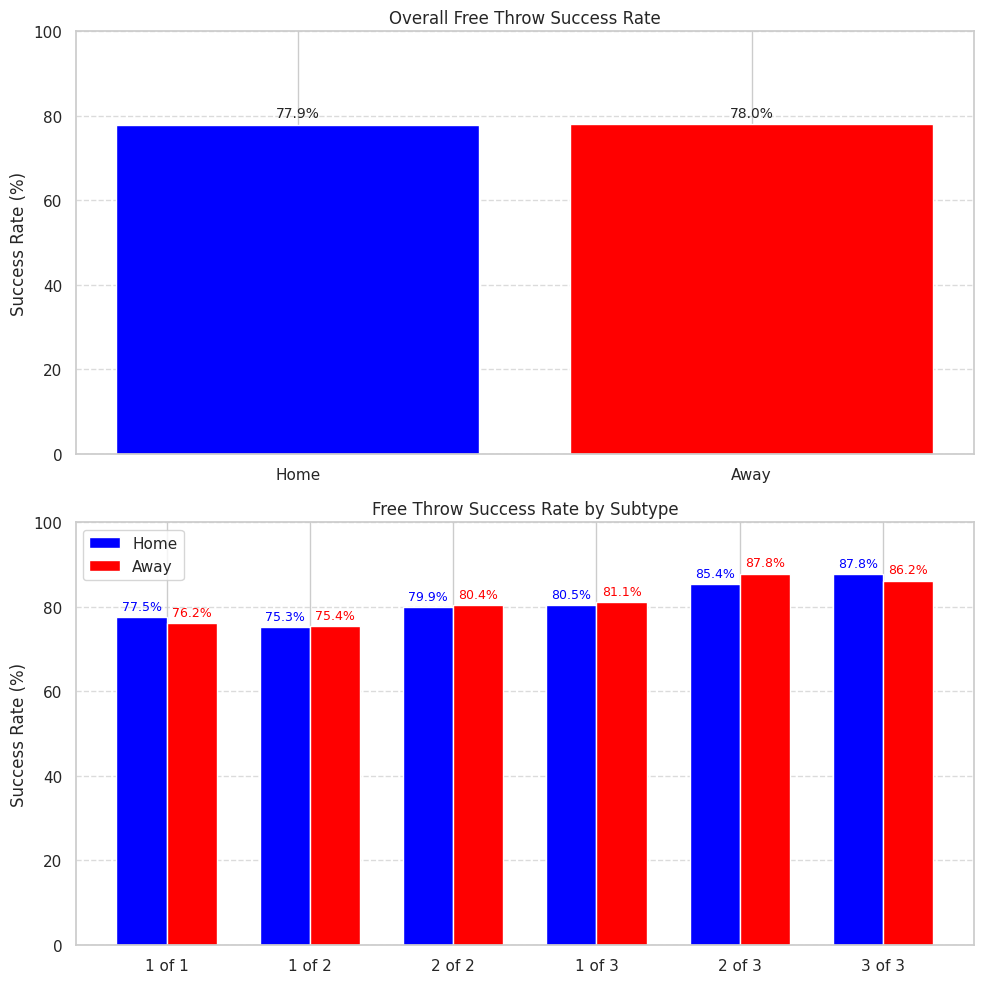

In [83]:
#prepare the information
subtypes_dt = ["1 of 1", "1 of 2", "2 of 2", "1 of 3", "2 of 3", "3 of 3"]
home_rates_dt = [home_1of1, home_1of2, home_2of2, home_1of3, home_2of3, home_3of3]
away_rates_dt = [away_1of1, away_1of2, away_2of2, away_1of3, away_2of3, away_3of3]
x = range(len(subtypes_dt))
bar_width = 0.35

# Create subplots (2 rows, 1 column)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,10))

# -----------------------
# 1. Overall success rate
# -----------------------
bars = ax1.bar(["Home", "Away"], [home_success_rate, away_success_rate], color=["blue", "red"])
ax1.set_title("Overall Free Throw Success Rate")
ax1.set_ylabel("Success Rate (%)")
ax1.set_ylim(0, 100)
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}%",
             ha="center", va="bottom", fontsize=10)

# -----------------------
# 2. Success rate by subtype
# -----------------------
bars_home = ax2.bar([i - bar_width/2 for i in x], home_rates_dt, width=bar_width, label="Home", color="blue")
bars_away = ax2.bar([i + bar_width/2 for i in x], away_rates_dt, width=bar_width, label="Away", color="red")

ax2.set_xticks(x)
ax2.set_xticklabels(subtypes_dt)
ax2.set_title("Free Throw Success Rate by Subtype")
ax2.set_ylabel("Success Rate (%)")
ax2.set_ylim(0, 100)
ax2.grid(axis="y", linestyle="--", alpha=0.7)
ax2.legend()

# Add value labels for home
for bar in bars_home:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}%",
             ha="center", va="bottom", fontsize=9, color="blue")

# Add value labels for away
for bar in bars_away:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}%",
             ha="center", va="bottom", fontsize=9, color="red")

plt.tight_layout()
plt.show()

## **Insights**

**Not exactly same**: Both Home and Away players shoot very similar FT% across all sequences.

**Slight trend**: As players progress in a sequence (2 of 3, 3 of 3), success rate tends to increase — possibly because the shooter is more “warmed up” after the first attempt.

**No strong bias**: There is no clear systematic difference between Home and Away in this dataset.